In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and inspect data

In [3]:
df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


We can inspect the types of feature columns using the following code:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

We will drop the Id column as it is not necessary for model training.

In [6]:
df = df.drop('Id', axis=1)
df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


# 2. House Price Distribution

Now let us take a look at how the house prices are distributed.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


/tmp/ipykernel_119/3731398740.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SalePrice'], color='g', bins= 100, hist_kws={'alpha': 0.4});


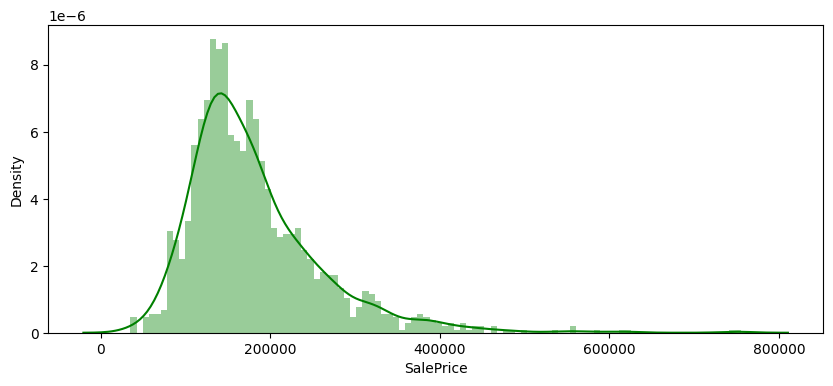

In [7]:
print(df['SalePrice'].describe())

plt.figure(figsize=(10,4))
sns.distplot(df['SalePrice'], color='g', bins= 100, hist_kws={'alpha': 0.4});

# 3. Numerical data distribution

We will now take a look at how the numerical features are distributed. In order to do this, let us first list all the types of data from our dataset and select only the numerical ones.

In [8]:
list(set(df.dtypes.to_list()))

[dtype('O'), dtype('float64'), dtype('int64')]

In [9]:
df_num = df.select_dtypes(include= ['float64', 'int64'])
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


# 4. Prepare the dataset

## Missing value

Checking where and how much data is missing before deciding whether a gap means "unknown" or "doesn't apply" — the fix depends entirely on which one it is.

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageCond       5.547945
GarageYrBlt      5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtFinType1     2.534247
BsmtCond         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


Text(0, 0.5, '% missing')

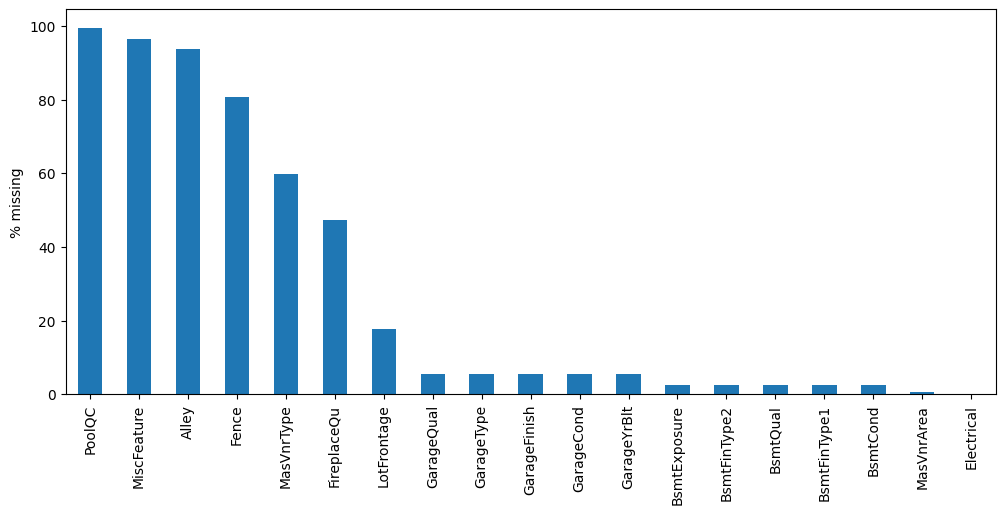

In [10]:
missing = df.isna().sum()
missing_pct = (missing/ len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

missing_pct[missing_pct > 0].plot(kind="bar", figsize=(12,5))
plt.ylabel("% missing")

b. Filling PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu with "None":

For these columns, NaN doesn't mean missing data — it means the feature doesn't exist for that house (no pool, no fence, no fireplace). Filling with "None" turns a blank into an honest category instead of losing the row's information.

In [11]:
none_fill_cols = ["PoolQC","MiscFeature","Alley","Fence","MasVnrType","FireplaceQu"]
df[none_fill_cols] = df[none_fill_cols].fillna("None")

If every row missing PoolQC also has PoolArea == 0, that confirms your theory numerically — missing genuinely means "no pool exists," not "we forgot to record it." 

In [12]:
print(df.loc[df["PoolQC"].isna(), "PoolArea"].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: PoolArea, dtype: float64


c. LotFrontage — the genuinely different one

Unlike the columns above, a missing LotFrontage is a genuine unknown (every house has some frontage) — so we estimate it using the median frontage within the same neighborhood, since lot layout is strongly location-dependent.

In [13]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

d. Re-running the missing value scan after fixes:

GarageType      5.547945
GarageFinish    5.547945
GarageYrBlt     5.547945
GarageCond      5.547945
GarageQual      5.547945
BsmtExposure    2.602740
BsmtFinType2    2.602740
BsmtCond        2.534247
BsmtQual        2.534247
BsmtFinType1    2.534247
MasVnrArea      0.547945
Electrical      0.068493
dtype: float64


Text(0, 0.5, '% missing')

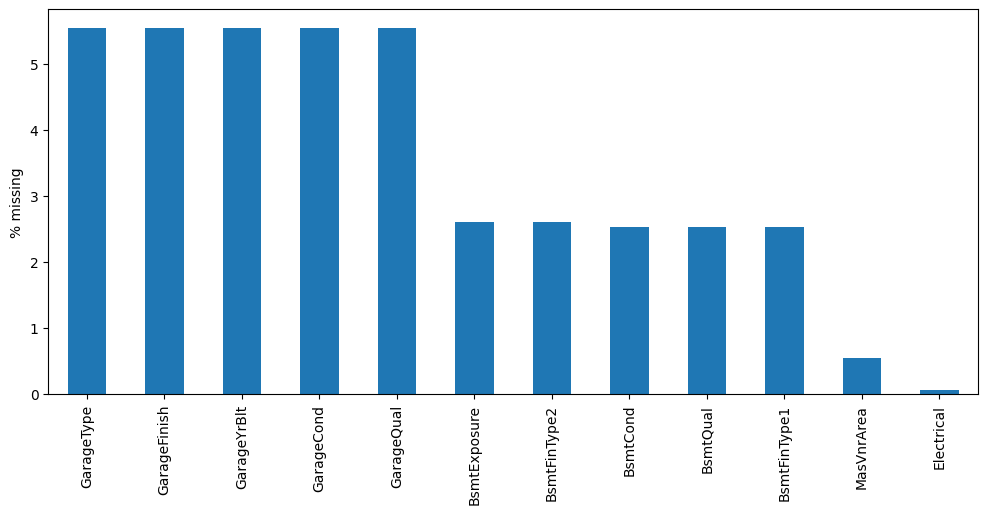

In [14]:
missing = df.isna().sum()
missing_pct = (missing/ len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

missing_pct[missing_pct > 0].plot(kind="bar", figsize=(12,5))
plt.ylabel("% missing")

e. GarageType, GarageFinish, GarageCond, GarageQual are all categorical → missing means no garage at all. No garage on the property means these descriptive fields were never filled in — "None" records that honestly instead of treating it as unknown data.

In [15]:
garage_cat_cols = ["GarageType","GarageFinish","GarageCond","GarageQual"]
df[garage_cat_cols] = df[garage_cat_cols].fillna("None")

f. GarageYrBlt is numeric, so "no garage" can't be written as a category — filling with 0 flags "no garage" without inventing a fake construction year. 

In [16]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

Confirming missing GarageType lines up with GarageArea = 0 — same cross-check discipline as we used for the pool.

In [17]:
print(df.loc[df["GarageType"].isna(), "GarageArea"].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: GarageArea, dtype: float64


Missing basement descriptors mean the house has no basement — filled as "None" for the same reason as the garage and pool columns.

In [18]:
bsmt_cat_cols = ["BsmtExposure","BsmtFinType2","BsmtCond","BsmtQual","BsmtFinType1"]
df[bsmt_cat_cols] = df[bsmt_cat_cols].fillna("None")

MasVnrArea is the numeric partner to MasVnrType — no veneer type means the veneer area is truly 0, not a data gap.

In [19]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

Electrical — the real outlier here

Only 0.068% missing (literally 1 row out of ~1460). This is fundamentally different from everything else above — every house has electrical wiring, so this isn't a "doesn't exist" case, it's a genuine, tiny, likely random gap (MCAR-type missingness — one record where the value just wasn't captured).

In [20]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

check the total remaining missing count across the whole dataframe

In [21]:
df.isna().sum().sum()

np.int64(0)

## Fixing data types

In [22]:
print(df.dtypes.to_string())

MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object
HeatingQC         object


MSSubClass looks numeric but is actually a category code for dwelling type — converting it to category prevents pandas (and any model) from treating it as a real quantity with a meaningful order or average.

In [23]:
df["MSSubClass"] = df["MSSubClass"].astype("category")

# 5. Univariate Analysis

## Step 1: Quantify SalePrice's skew

/tmp/ipykernel_119/3182910630.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SalePrice'], color='g', bins= 100, hist_kws={'alpha': 0.4});


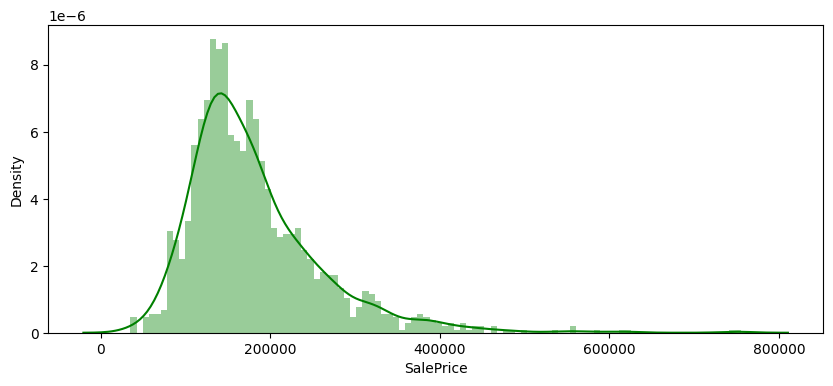

In [24]:
plt.figure(figsize=(10,4))
sns.distplot(df['SalePrice'], color='g', bins= 100, hist_kws={'alpha': 0.4});

Skew() quantifies what the distplot showed visually — a number over ~1 confirms strong right-skew, which tells us a log-transform is worth applying before modeling, not just eyeballing "it looks skewed."

In [25]:
print('Skewness', df['SalePrice'].skew())
print('Kurt', df['SalePrice'].kurt())
df["SalePrice"].describe()

Skewness 1.8828757597682129
Kurt 6.536281860064529


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Step 2: Apply the log-transform and compare

SalePrice is right-skewed; Linear Regression works best when the target is roughly normal, so log1p compresses the long tail of expensive houses without losing any data — we'll train the model on SalePrice_log and reverse the transform (np.expm1) when reporting real dollar predictions.

Skewness after log: 0.12134661989685333


Text(0.5, 1.0, 'Log-transformed')

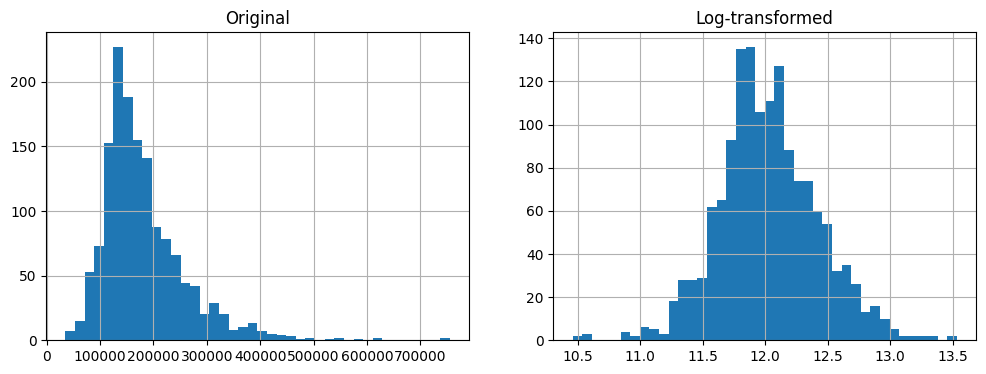

In [26]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])
print('Skewness after log:', df['SalePrice_log'].skew())

fig, ax = plt.subplots(1, 2, figsize=(12,4))
df["SalePrice"].hist(ax=ax[0], bins=40); ax[0].set_title("Original")
df["SalePrice_log"].hist(ax=ax[1], bins=40); ax[1].set_title("Log-transformed")

## Step 3: Now do the same skim across ALL numeric columns at once

Scanning skew across every numeric column at once flags which features are heavily skewed — these are candidates for a log-transform later, the same fix we just applied to SalePrice.

In [27]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
skew_values = df[numeric_cols].skew().sort_values(ascending=False)
print(skew_values)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
OpenPorchSF       2.364342
LotFrontage       2.212959
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
SalePrice_log     0.121347
YrSold            0.096269
FullBath          0.036562
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
GarageYrBlt      -3.869501
d

## Step 4: Visualize the whole numeric block together

Plotting every numeric column's histogram in one grid gives a fast visual scan for skew, near-constant columns, and unusual distributions — faster than reviewing each column one plot at a time.

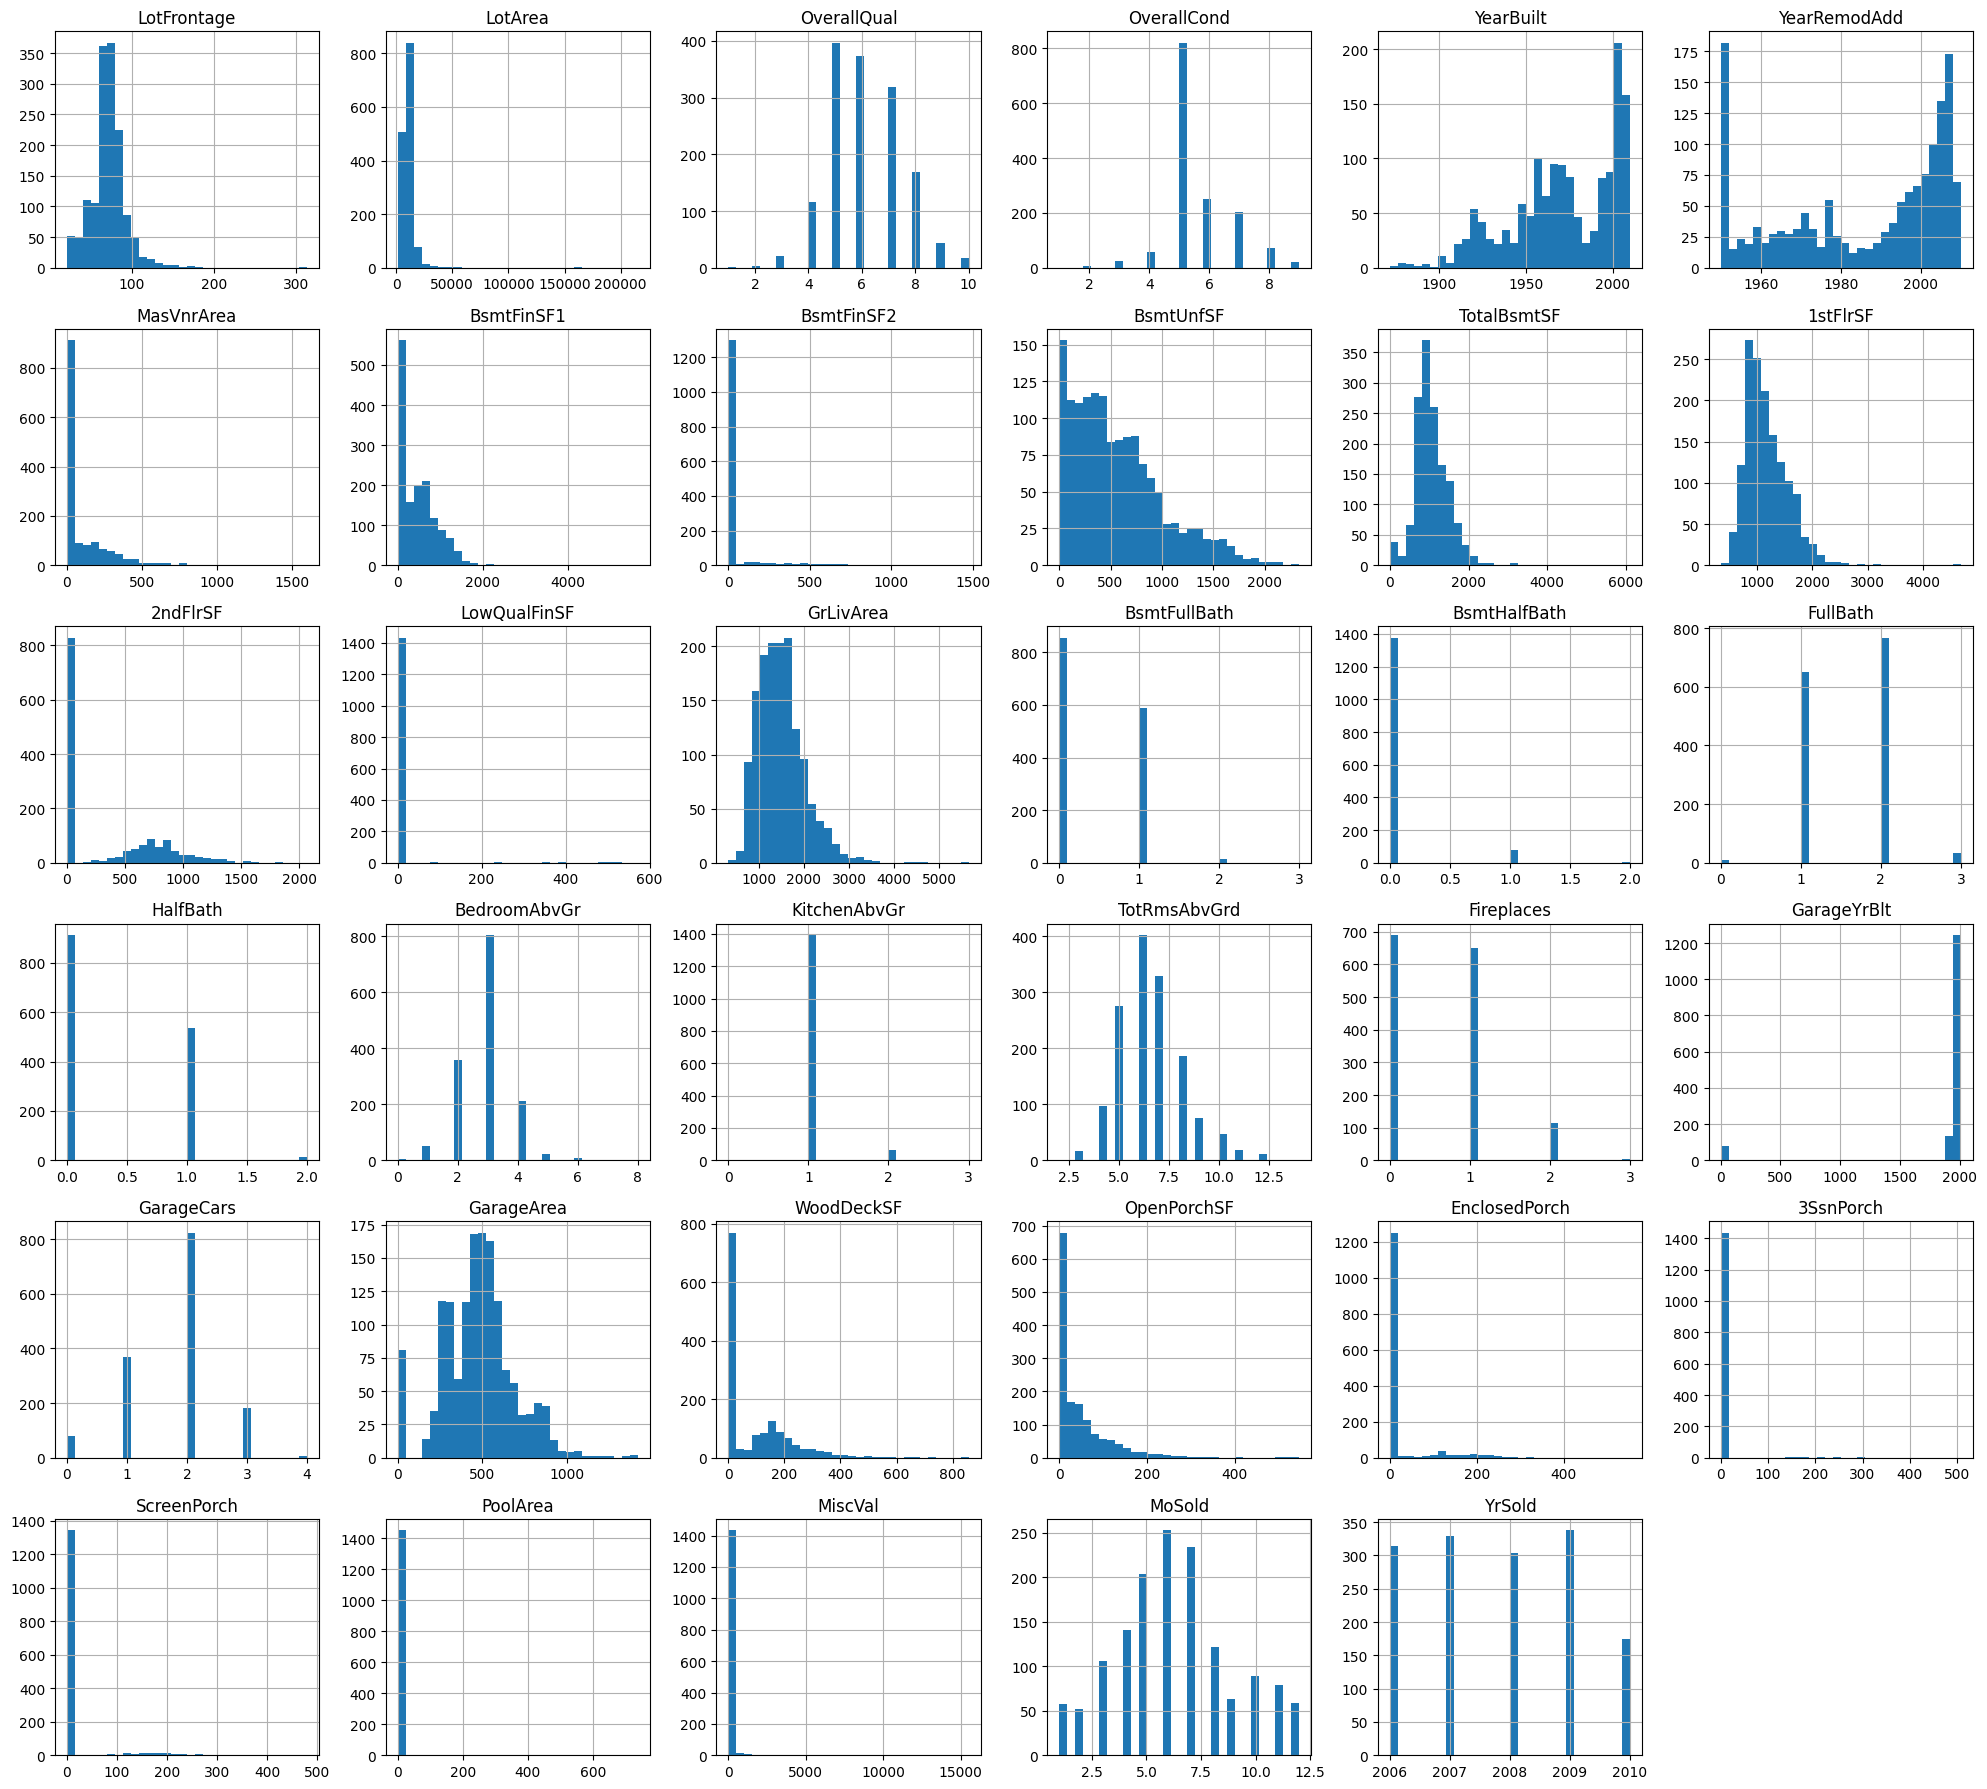

In [28]:
numeric_cols_no_target = [c for c in numeric_cols if c not in ["SalePrice","SalePrice_log"]]

df[numeric_cols_no_target].hist(figsize=(20,18), bins=30)
plt.tight_layout()

Skewness only applies to numeric data since it's a mathematical distance-from-mean calculation. For categorical columns, value_counts() plays the same role — revealing whether one category dominates (imbalanced) the same way skew reveals whether values cluster to one side.

In [29]:
for col in df.select_dtypes(include="object").columns:
    print(col, ":", df[col].nunique(), "unique values")
    print(df[col].value_counts(normalize=True).head())
    print()

MSZoning : 5 unique values
MSZoning
RL         0.788356
RM         0.149315
FV         0.044521
RH         0.010959
C (all)    0.006849
Name: proportion, dtype: float64

Street : 2 unique values
Street
Pave    0.99589
Grvl    0.00411
Name: proportion, dtype: float64

Alley : 3 unique values
Alley
None    0.937671
Grvl    0.034247
Pave    0.028082
Name: proportion, dtype: float64

LotShape : 4 unique values
LotShape
Reg    0.633562
IR1    0.331507
IR2    0.028082
IR3    0.006849
Name: proportion, dtype: float64

LandContour : 4 unique values
LandContour
Lvl    0.897945
Bnk    0.043151
HLS    0.034247
Low    0.024658
Name: proportion, dtype: float64

Utilities : 2 unique values
Utilities
AllPub    0.999315
NoSeWa    0.000685
Name: proportion, dtype: float64

LotConfig : 5 unique values
LotConfig
Inside     0.720548
Corner     0.180137
CulDSac    0.064384
FR2        0.032192
FR3        0.002740
Name: proportion, dtype: float64

LandSlope : 3 unique values
LandSlope
Gtl    0.946575
Mod    

1. Utilities, Street, PoolQC, Condition2, RoofMatl, Heating columns are so dominated by a single category that there's almost no variation left to explain SalePrice with — strong candidates for dropping in feature selection, the same logic as a near-zero-variance numeric column.

2. Neighborhood (25 categories, nicely spread, no single one over ~15%), HouseStyle, Exterior1st/Exterior2nd, BsmtFinType1, Foundation all show healthy variation across several categories. These are the categorical columns most likely to carry real predictive signal — good candidates to prioritize in the upcoming bivariate analysis.

3. Imbalance alone isn't a reason to drop a column — CentralAir is 93/6 but likely still predictive. Only extremely imbalanced columns (99%+) with a tiny remaining sample size are true drop candidates.

# 6. Bivariate analysis 

which of the features (numeric and categorical) actually relate to SalePrice.

Ranking every numeric column's correlation with SalePrice gives a fast first pass at which features likely matter — high correlation (positive or negative) flags a strong candidate; near-zero correlation flags a weak one, to be double-checked with a scatter plot before dropping.

In [30]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlations = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print(correlations)

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


In [31]:
top_features = correlations.drop(["SalePrice", "SalePrice_log"]).sort_values(ascending=False).head(7)
print(top_features.to_markdown())

|             |   SalePrice |
|:------------|------------:|
| OverallQual |    0.790982 |
| GrLivArea   |    0.708624 |
| GarageCars  |    0.640409 |
| GarageArea  |    0.623431 |
| TotalBsmtSF |    0.613581 |
| 1stFlrSF    |    0.605852 |
| FullBath    |    0.560664 |


| Feature | Correlation with SalePrice | What it physically means |
|---|---|---|
| OverallQual | 0.79 | Overall material/finish quality rating |
| GrLivArea | 0.71 | Above-ground living area (sq ft) |
| GarageCars | 0.64 | Garage capacity (cars) |
| GarageArea | 0.62 | Garage size (sq ft) |
| TotalBsmtSF | 0.61 | Total basement area |
| 1stFlrSF | 0.61 | First floor area |
| FullBath | 0.56 | Number of full bathrooms |

GarageCars and GarageArea rank similarly against SalePrice, suggesting they capture overlapping information — worth checking their correlation with each other before deciding whether to keep both or drop one during feature selection.

In [32]:
print(df[["GarageCars","GarageArea"]].corr())

            GarageCars  GarageArea
GarageCars    1.000000    0.882475
GarageArea    0.882475    1.000000


The near-zero group — likely drop candidates
MoSold (0.046), 3SsnPorch (0.045), BsmtFinSF2 (-0.011), BsmtHalfBath (-0.017), MiscVal (-0.021), LowQualFinSF (-0.026), YrSold (-0.029) — all essentially no linear relationship with SalePrice.

Near-zero correlation doesn't automatically mean "no relationship" — Pearson only catches LINEAR relationships. A column like YrSold could still matter through a non-linear pattern (like a market crash year), which is why we'll look at a few of these visually before fully dropping them.

One genuinely surprising one: OverallCond at -0.078

This is worth pausing on specifically, because it looks backwards at first glance — you'd expect "better condition = higher price," but the correlation is slightly negative. This is a great one to investigate.

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

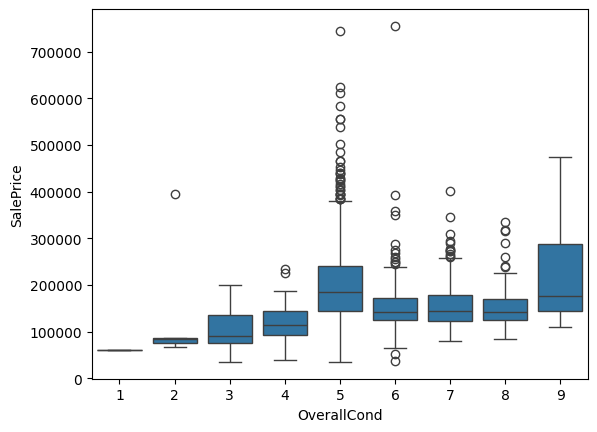

In [33]:
sns.boxplot(x="OverallCond", y="SalePrice", data=df)

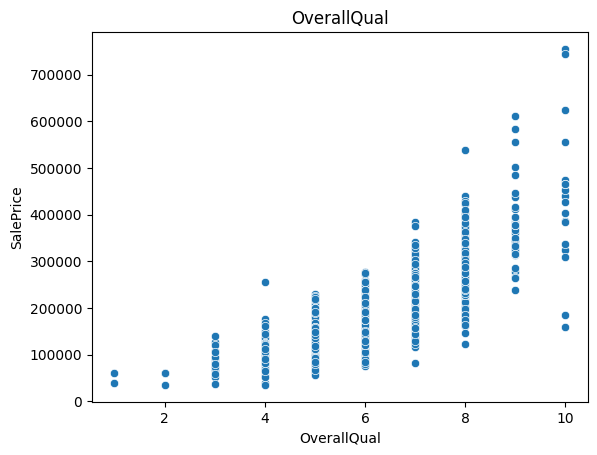

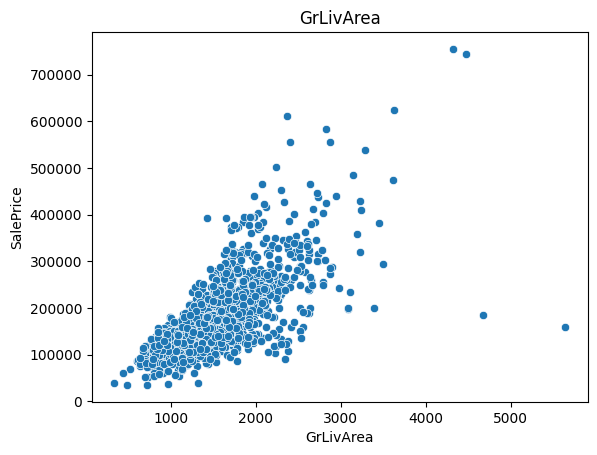

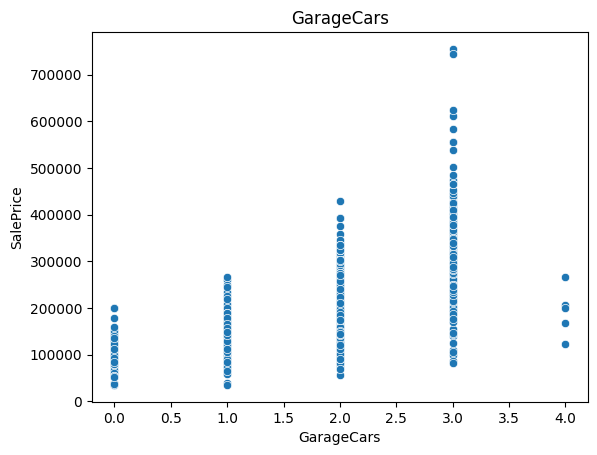

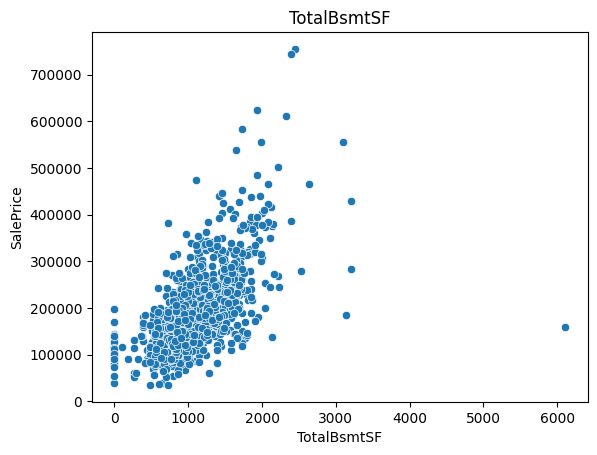

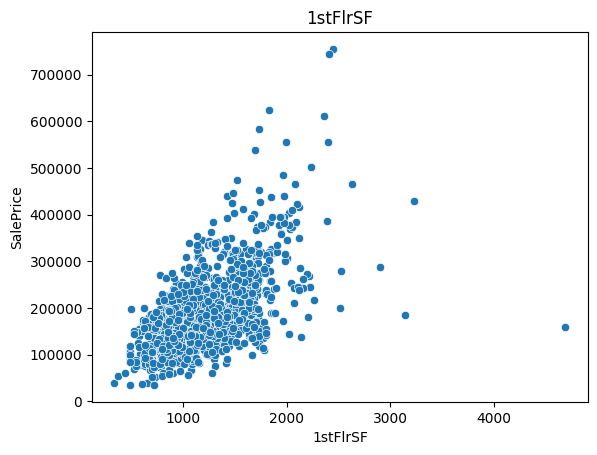

In [34]:
for col in ["OverallQual","GrLivArea","GarageCars","TotalBsmtSF","1stFlrSF"]:
    sns.scatterplot(x=col, y="SalePrice", data=df)
    plt.title(col)
    plt.show()

In [35]:
df[df["GrLivArea"] > 4000][["GrLivArea", "SalePrice", "OverallQual", "SaleCondition"]]

,GrLivArea,SalePrice,OverallQual,SaleCondition
523,4676,184750,10,Partial
691,4316,755000,10,Normal
1182,4476,745000,10,Abnorml
1298,5642,160000,10,Partial


Several of these outlier rows have SaleCondition = "Partial" or "Abnorml" rather than "Normal". This is the actual explanation — a "Partial" sale often means the house was sold before construction was fully complete (common for new-construction sales), and "Abnorml" covers things like foreclosures, short sales, or family sales at a discount. These aren't data-entry mistakes — they're real transactions, just not representative of a normal arm's-length sale. A huge, unfinished house sold at a discount naturally breaks the "bigger house = higher price" pattern, for a completely legitimate reason.

In [36]:
df[df["GrLivArea"] > 4000][["GrLivArea","SalePrice","SaleCondition","YrSold"]]

,GrLivArea,SalePrice,SaleCondition,YrSold
523,4676,184750,Partial,2007
691,4316,755000,Normal,2007
1182,4476,745000,Abnorml,2007
1298,5642,160000,Partial,2008


Removed GrLivArea outliers above 4000 sqft with anomalously low SalePrice — investigation showed these are Partial/Abnormal sale conditions (unfinished construction, foreclosures), not normal market transactions, so they'd mislead a Linear Regression model's fitted trend without adding real signal about typical home pricing.

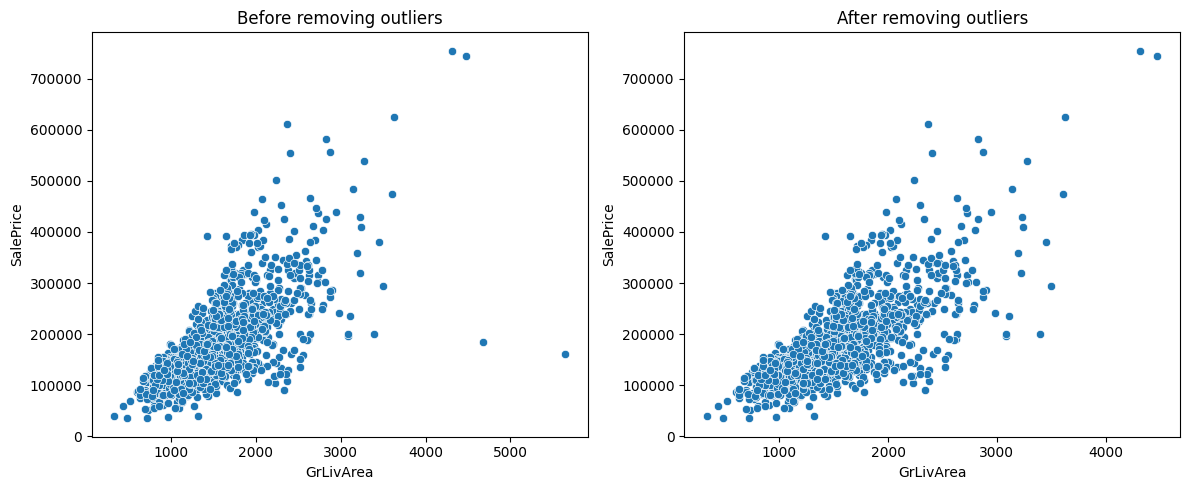

In [37]:
# take a snapshot BEFORE dropping anything
df_before = df.copy()

# identify and drop the outliers
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
df_after = df.drop(outliers.index)

# now plot both, side by side
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(x="GrLivArea", y="SalePrice", data=df_before, ax=ax[0])
ax[0].set_title("Before removing outliers")

sns.scatterplot(x="GrLivArea", y="SalePrice", data=df_after, ax=ax[1])
ax[1].set_title("After removing outliers")

plt.tight_layout()
plt.show()

Categorical vs SalePrice boxplots for Top Candidates (Neighborhood, HouseStyle, ExterQual, KitchenQual, Foundation):

Using boxplots instead of bar charts to compare SalePrice across categories — this shows the full spread and overlap per category, not just the average, which tells us whether a category can actually help the model distinguish price ranges.

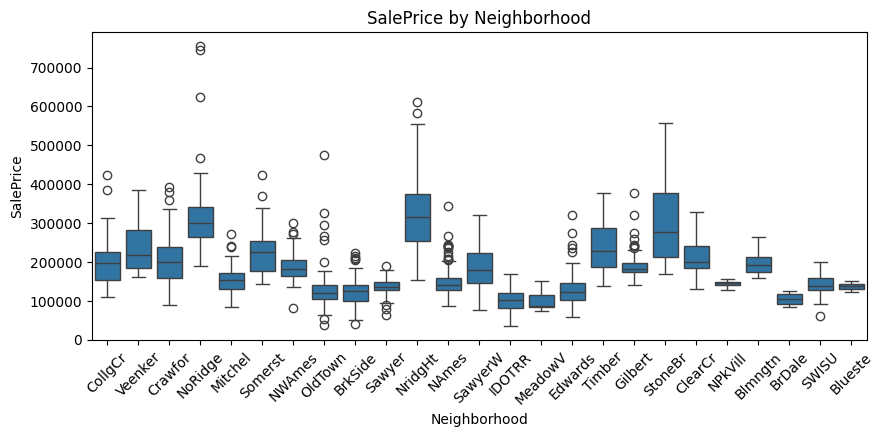

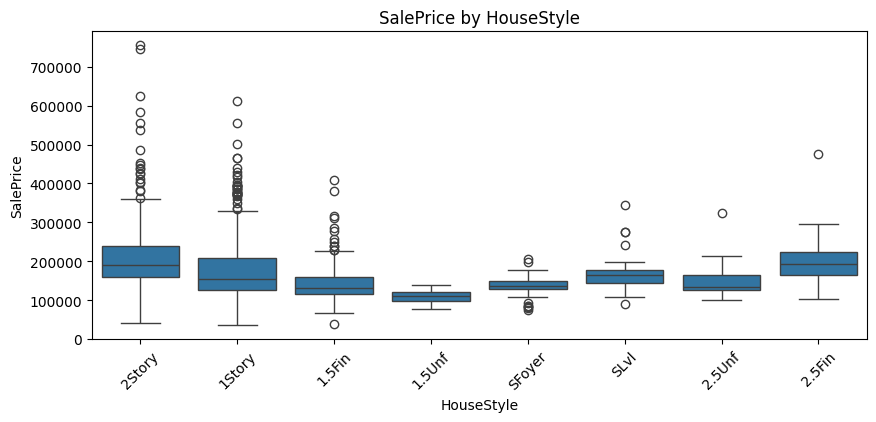

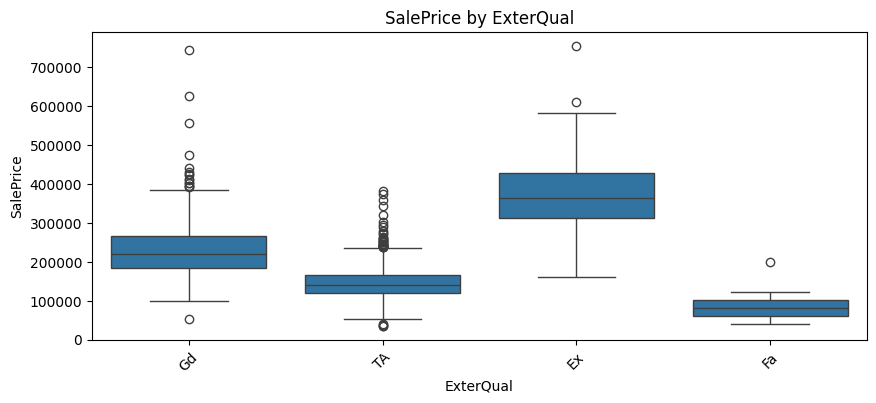

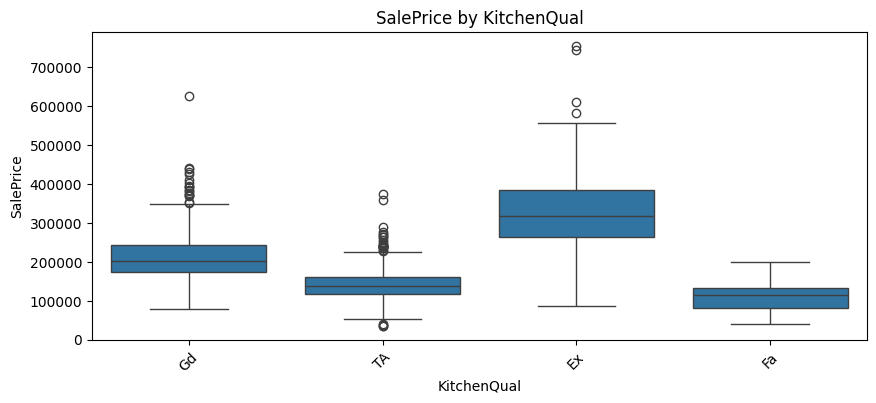

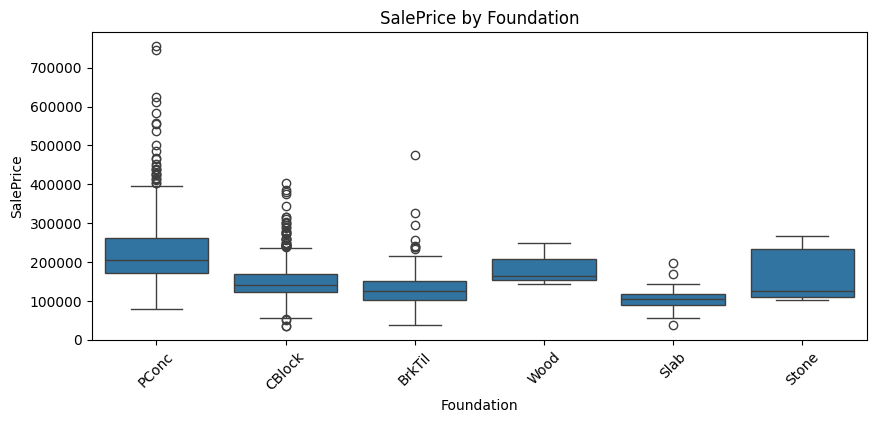

In [38]:
for col in ["Neighborhood", "HouseStyle", "ExterQual", "KitchenQual", "Foundation"]:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=col, y="SalePrice", data=df)
    plt.xticks(rotation=45)
    plt.title(f"SalePrice by {col}")
    plt.show()

Question: Does Neighborhood actually relate to SalePrice, or does the variation you saw in the boxplot just reflect random sampling noise across the 25 groups?

1. H0 (null hypothesis): All neighborhoods have the same true average SalePrice. Any differences you see in the sample are just random noise — if you drew a different 
sample of house sales, the ranking of "priciest neighborhood" could shuffle around.

2. H1 (alternative hypothesis): At least one neighborhood's true average SalePrice is genuinely different from the others.

**Hypothesis — Neighborhood vs SalePrice**
H0: All neighborhoods have the same true average SalePrice (observed differences are random noise)
H1: At least one neighborhood's true average SalePrice differs significantly

We test this before trusting the boxplot's visual separation as a real, model-worthy signal.

Formal validation — ANOVA on the strongest-looking categorical

In [39]:
from scipy import stats

groups = [g['SalePrice'].values for _, g in df.groupby('Neighborhood')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F={f_stat:.3f}, p={p_value:.4f}")

if p_value < 0.05:
    print("Reject H0. Neighborhood has a statistically significant effect on SalePrice")
else:
    print("Fail to reject H0. No significant difference across neighborhoods")

F=71.785, p=0.0000
Reject H0. Neighborhood has a statistically significant effect on SalePrice


# 7. Feature Engineering

In [40]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

## Feature 1: HouseAge

In [41]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df["YearsSinceRemodel"] = df["YrSold"] - df["YearRemodAdd"]

HouseAge and YearsSinceRemodel convert raw year columns into the actually-meaningful "how old/how fresh" signal — a model can't infer this relationship on its own from two separate year columns, so we compute it directly.

In [42]:
print(df[["HouseAge","YearsSinceRemodel","SalePrice"]].corr()["SalePrice"])

HouseAge            -0.523350
YearsSinceRemodel   -0.509079
SalePrice            1.000000
Name: SalePrice, dtype: float64


HouseAge and YearsSinceRemodel both show real, comparable negative correlation with SalePrice (confirming older/less-recently-renovated houses sell for less), but they may be correlated with each other too — flagged for the feature-selection step later, same as GarageCars/GarageArea.

In [43]:
print(df[["HouseAge","YearsSinceRemodel"]].corr())

                   HouseAge  YearsSinceRemodel
HouseAge           1.000000           0.594195
YearsSinceRemodel  0.594195           1.000000


## Feature 2: TotalSF — combining the size-related columns

Combining TotalBsmtSF, 1stFlrSF, and 2ndFlrSF into TotalSF gives the model the actual "total usable space" concept directly — a linear model can't learn to add columns together on its own, so engineering the sum explicitly captures a stronger signal than any individual floor area alone.

In [44]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

In [45]:
print(df[["TotalSF","SalePrice"]].corr())

           TotalSF  SalePrice
TotalSF    1.00000    0.78226
SalePrice  0.78226    1.00000


TotalSF is mathematically derived from TotalBsmtSF/1stFlrSF/2ndFlrSF, so it will be highly correlated with all three — feature selection will likely keep TotalSF alone and drop the individual components to avoid redundancy.

## Feature 3: Binary "has X" flags — for the mostly-zero columns

In [46]:
df["HasPool"] = (df["PoolArea"] > 0).astype(int)
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

Why a binary flag instead of the raw skewed number, for these specific columns: recall the earlier discussion — columns like PoolArea are skewed not because of a smooth long tail (like SalePrice), but because almost every value is exactly 0, with a small minority nonzero. A log-transform doesn't fix that shape meaningfully — what actually matters to price isn't "how many square feet is the pool," it's simply "does this house have a pool at all." The presence/absence is the real signal; the exact size is a much weaker, noisier secondary detail.

In [47]:
for col in ["HasPool","HasFireplace","HasGarage","Has2ndFloor","HasBasement"]:
    print(col, ":", df.groupby(col)["SalePrice"].mean())

HasPool : HasPool
0    180404.663455
1    288138.571429
Name: SalePrice, dtype: float64
HasFireplace : HasFireplace
0    141331.482609
1    216397.692208
Name: SalePrice, dtype: float64
HasGarage : HasGarage
0    103317.283951
1    185479.511240
Name: SalePrice, dtype: float64
Has2ndFloor : Has2ndFloor
0    171383.670688
1    193451.478605
Name: SalePrice, dtype: float64
HasBasement : HasBasement
0    105652.891892
1    182878.277583
Name: SalePrice, dtype: float64


In [48]:
print(df["HasPool"].value_counts())   # how many houses actually have a pool?

# check if pool-houses are also high on other value drivers
print(df.groupby("HasPool")[["OverallQual","GrLivArea","TotalSF"]].mean())

HasPool
0    1453
1       7
Name: count, dtype: int64
         OverallQual    GrLivArea      TotalSF
HasPool                                       
0           6.092223  1508.558156  2555.781142
1           7.571429  2948.857143  4905.857143


HasPool showed the largest SalePrice gap of all flags, which is surprising given how few houses have one — checked whether pool-owning houses are also larger/higher-quality overall, since a tiny high-value cluster (rather than the pool itself) could be driving the gap, the same confounding pattern discussed with correlation vs causation

Only 7 houses out of 1460 have a pool. And look at the other columns for that group:

1. OverallQual: 7.57 vs 6.09 for non-pool houses — noticeably higher quality
2. GrLivArea: 2,949 vs 1,509 sq ft — almost double the living area
3. TotalSF: 4,906 vs 2,556 sq ft — again, almost double

Houses with pools aren't just "regular houses plus a pool" — they're a fundamentally different category of house: much bigger, much higher quality, essentially mansions. The $107k price gap we saw isn't really "a pool is worth $107k" — it's "houses that happen to have pools are also nearly twice the size and a full quality-point higher, and that's what's actually driving the price difference." The pool is riding along with the real cause, not causing it itself.


On top of the confounding issue, there's a second, equally important problem: sample size. With only 7 positive cases, HasPool is close to the near-zero-variance territory.

HasPool's large SalePrice gap is confounded — pool-owning houses are nearly 2x the size and a full quality-point higher on average, meaning size/quality (already captured by OverallQual and TotalSF) is the real driver, not the pool itself. Combined with only 7 positive cases, HasPool is a strong drop candidate for feature selection.

# 8. Feature Selection 

More features doesn't automatically mean a better model — extra, redundant, or irrelevant columns can actively hurt performance, not just sit there harmlessly.

## Step 1: Near-zero variance categorical columns - drop

Dropping columns where one category dominates 97%+ of rows — near-zero variance means the model has almost no contrast to learn a real pattern from.

In [49]:
near_zero_var_cols = ["Utilities", "Street", "PoolQC", "Condition2", "RoofMatl", "Heating"]

for col in near_zero_var_cols:
    print(col, df[col].value_counts(normalize=True).iloc[0])

df = df.drop(columns=near_zero_var_cols)

Utilities 0.9993150684931507
Street 0.9958904109589041
PoolQC 0.9952054794520548
Condition2 0.9897260273972602
RoofMatl 0.9821917808219178
Heating 0.9780821917808219


## Step 2: Redundant numeric pairs

In [50]:
print(df[["GarageCars","GarageArea", "SalePrice"]].corr())

            GarageCars  GarageArea  SalePrice
GarageCars    1.000000    0.882475   0.640409
GarageArea    0.882475    1.000000   0.623431
SalePrice     0.640409    0.623431   1.000000


In [51]:
df = df.drop(columns=["GarageArea"])

Keeping GarageCars over GarageArea since it correlates slightly more strongly with SalePrice — dropping the redundant twin avoids multicollinearity without losing signal.

In [52]:
print(df[["HouseAge","YearsSinceRemodel"]].corr())

                   HouseAge  YearsSinceRemodel
HouseAge           1.000000           0.594195
YearsSinceRemodel  0.594195           1.000000


Since the correlation between HouseAge and YearsSinceRemodel is not more than 0.7+ we can keep both.

## Step 3: Drop source columns of TotalSF

TotalSF already captures the combined signal of these three columns — keeping all four would feed the model the same information multiple times over.

In [53]:
df = df.drop(columns=["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"])

## Step 4: Drop HasPool

HasPool's apparent effect was confounded by house size/quality (already captured by TotalSF and OverallQual), and only 7 positive samples exist — not enough data to trust, and mostly redundant anyway.

In [54]:
df = df.drop(columns=["HasPool", "PoolArea"])

## Step 5: Drop Numeric Columns whose correlation with Sale Price is near zero

Dropping numeric columns whose correlation with SalePrice was near-zero — they add noise without meaningful predictive signal.

In [55]:
weak_corr_cols = ["MoSold","3SsnPorch","BsmtFinSF2","BsmtHalfBath","MiscVal","LowQualFinSF","YrSold"]
df = df.drop(columns=weak_corr_cols)

## Step 6: Final Check of Multicollinearity — VIF

VIF checks if any remaining feature is a linear combination of SEVERAL other features at once — catching redundancy that a simple pairwise correlation check might miss.

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = df.select_dtypes(include=["int64","float64"]).columns.drop(["SalePrice","SalePrice_log"])
X = df[num_cols].dropna()

vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=num_cols
)
print(vif.sort_values(ascending=False))

YearBuilt                     inf
YearRemodAdd                  inf
HouseAge                      inf
YearsSinceRemodel             inf
GarageYrBlt          2.389184e+04
HasGarage            2.317703e+04
TotalSF              3.817502e+02
GrLivArea            2.588192e+02
TotRmsAbvGrd         8.182533e+01
HasBasement          6.653442e+01
OverallQual          6.623716e+01
OverallCond          4.149377e+01
KitchenAbvGr         3.441269e+01
BedroomAbvGr         3.026857e+01
FullBath             2.637427e+01
BsmtUnfSF            2.226580e+01
GarageCars           2.122235e+01
BsmtFinSF1           1.708597e+01
LotFrontage          1.572062e+01
HasFireplace         1.278705e+01
Fireplaces           1.200686e+01
Has2ndFloor          6.642637e+00
HalfBath             3.417770e+00
BsmtFullBath         3.369858e+00
LotArea              2.722211e+00
WoodDeckSF           1.905578e+00
MasVnrArea           1.832315e+00
OpenPorchSF          1.810286e+00
EnclosedPorch        1.437412e+00
ScreenPorch   

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF > 5-10 means a feature is largely explainable by the other features — a red flag for multicollinearity.

Why YearBuilt, YearRemodAdd, HouseAge, YearsSinceRemodel all show inf
This is a direct consequence of a mistake worth understanding clearly: HouseAge and YearsSinceRemodel were built directly FROM YearBuilt and YearRemodAdd.

We engineered HouseAge specifically because it's more meaningful than YearBuilt alone — that reasoning was correct. The mistake now is keeping both the engineered feature AND its raw source column in the model at the same time. That's the redundancy VIF is catching.

In [57]:
df = df.drop(columns=["YearBuilt", "YearRemodAdd"])

GarageYrBlt was filled with 0 for houses with no garage (remember that fix from missing-value handling). That means GarageYrBlt == 0 is now perfectly predictable from HasGarage == 0 — they're encoding almost the exact same information (has a garage / doesn't have one), just through different columns. This is a side-effect of our own missing-value fix creating a new redundancy downstream 

In [58]:
df = df.drop(columns=["GarageYrBlt"])

In [59]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.drop(["SalePrice","SalePrice_log"])
X = df[num_cols].dropna()

vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=num_cols
)
print(vif.sort_values(ascending=False))

TotalSF              373.264936
GrLivArea            256.714706
TotRmsAbvGrd          81.704530
OverallQual           55.162428
HasBasement           50.190624
OverallCond           36.681230
BedroomAbvGr          30.005377
HasGarage             29.398005
KitchenAbvGr          26.417219
FullBath              25.373350
BsmtUnfSF             22.213499
GarageCars            19.252008
BsmtFinSF1            17.058291
LotFrontage           15.261623
HasFireplace          12.769643
Fireplaces            11.887315
HouseAge              10.273083
Has2ndFloor            6.372894
YearsSinceRemodel      4.654763
HalfBath               3.392813
BsmtFullBath           3.359776
LotArea                2.715549
WoodDeckSF             1.891093
MasVnrArea             1.828269
OpenPorchSF            1.803367
EnclosedPorch          1.436446
ScreenPorch            1.183535
dtype: float64


Dropped YearBuilt, YearRemodAdd, and GarageYrBlt — their engineered replacements (HouseAge, YearsSinceRemodel, HasGarage) captured the same information in a more meaningful form, and keeping both the raw and engineered versions created perfect multicollinearity (VIF = inf).

The two biggest remaining numbers: TotalSF (373) and GrLivArea (257)

GrLivArea (above-ground living area) in this dataset is essentially 1stFlrSF + 2ndFlrSF (+ some minor low-quality finished area). So TotalSF = GrLivArea + TotalBsmtSF, roughly. These two columns share almost their entire content — GrLivArea is basically a subset of what TotalSF already contains.

In [60]:
print(df[["TotalSF","GrLivArea"]].corr())

            TotalSF  GrLivArea
TotalSF    1.000000   0.874373
GrLivArea  0.874373   1.000000


Since both TotalSF and GrLivArea is highly correlated, we need to drop one. Which one to drop we can decide by checking correlation of both with SalePrice . Higher correlation one between TotalSF and GrLivArea we should keep.

In [61]:
print(df[["TotalSF","GrLivArea", 'SalePrice']].corr())

            TotalSF  GrLivArea  SalePrice
TotalSF    1.000000   0.874373   0.782260
GrLivArea  0.874373   1.000000   0.708624
SalePrice  0.782260   0.708624   1.000000


In [62]:
df = df.drop(columns = ['GrLivArea'])

TotalSF and GrLivArea overlap heavily (GrLivArea is nearly a subset of TotalSF's components) — kept TotalSF since it correlates more strongly with SalePrice and captures basement space GrLivArea misses entirely.

TotRmsAbvGrd (82) — also tied to the same size story
Total rooms above grade is naturally very correlated with square footage — bigger houses have more rooms, almost by definition. It's not perfectly redundant (a house could have many small rooms or few large ones), but it's clearly overlapping with the size cluster (TotalSF, GrLivArea already dropped, BedroomAbvGr, FullBath).

In [63]:
print(df[["TotRmsAbvGrd","SalePrice"]].corr())

              TotRmsAbvGrd  SalePrice
TotRmsAbvGrd      1.000000   0.533723
SalePrice         0.533723   1.000000


It's meaningfully weaker than TotalSF's 0.78 (likely — room count is a cruder signal than actual square footage), it's a reasonable drop. 

In [64]:
df = df.drop(columns=['TotRmsAbvGrd'])

VIF flags overlap with other kept features, not uselessness — OverallQual has high VIF but remains one of the strongest predictors. We only removed the clearest, most redundant pairs (raw years vs. engineered age, GrLivArea vs. TotalSF) rather than chasing every high-VIF column.

# 9. Train-test split:

Splitting before encoding now, since every encoder below must be fit only on X_train — encoding the full dataset first would leak test-set category information into training.

In [65]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice", "SalePrice_log"])
y = df["SalePrice_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 10. Encoding

Nominal columns get one-hot encoded since they have no natural order; ordinal quality ratings get a manual number mapping since "Excellent > Good > Average" is a real order the model should learn from.

## One-hot encode nominal columns with OneHotEncoder

In [66]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

nominal_cols = ["Neighborhood", "HouseStyle", "Foundation", "BldgType", "SaleType", "SaleCondition"]

ohe = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
ohe.fit(X_train[nominal_cols])

train_ohe = pd.DataFrame(
    ohe.transform(X_train[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_train.index
)
test_ohe = pd.DataFrame(
    ohe.transform(X_test[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_test.index
)

X_train = X_train.drop(columns=nominal_cols).join(train_ohe)
X_test = X_test.drop(columns=nominal_cols).join(test_ohe)

Fit the encoder only on X_train, then transform both — guarantees train and test end up with identical columns, and handle_unknown="ignore" prevents a crash if the test set ever contains a category the training set never saw.

## Ordinal-encode the quality-rating columns

In [67]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ["KitchenQual", "ExterQual", "ExterCond", "BsmtQual", "HeatingQC"]
quality_order = ["None","Po","Fa","TA","Gd","Ex"]

oe = OrdinalEncoder(categories=[quality_order] * len(ordinal_cols), handle_unknown="use_encoded_value", unknown_value=-1)
oe.fit(X_train[ordinal_cols])

X_train[ordinal_cols] = oe.transform(X_train[ordinal_cols])
X_test[ordinal_cols] = oe.transform(X_test[ordinal_cols])

*categories=[quality_order]len(ordinal_cols) applies the same Po<Fa<TA<Gd<Ex order to every listed column, since sklearn would otherwise guess alphabetical order — which is wrong here (it would rank "Ex" as low, "TA" as high).

# 11. Scaling

StandardScaler is applied since Linear Regression is scale-sensitive — without it, a feature like TotalSF (range in thousands) would dominate a feature like OverallQual (range 1-10) purely due to scale, not actual importance.

In [68]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Scaling — fit vs transform:

fit_transform only on training data, transform (not fit) on test data — fitting on test data would leak its statistics into training and inflate our evaluation results.